<a href="https://colab.research.google.com/github/mehrnazeraeisi/Spectral-Clustering/blob/main/Cockroach_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

بردار ویژه دوم (u2): [-0.367 -0.367 -0.367 -0.304 -0.063 -0.    -0.     0.063  0.304  0.367
  0.367  0.367]


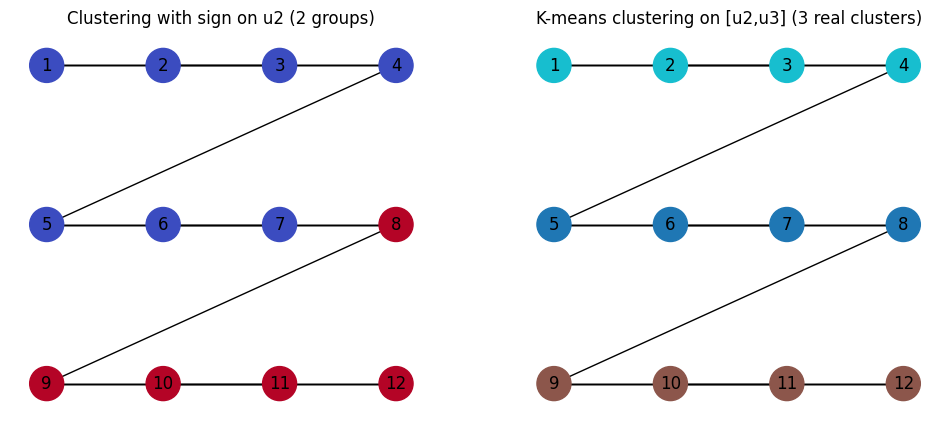

In [3]:
import numpy as np
import networkx as nx
from scipy.linalg import eigh
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# 1. ساخت گراف سوسکی 12 راسه با 3 خوشه واقعی
# -----------------------------
G = nx.Graph()

# خوشه 1: v1,v2,v3,v4
edges1 = [(1,2),(2,3),(3,4),(1,4),(1,3),(2,4)]
# خوشه 2: v5,v6,v7,v8
edges2 = [(5,6),(6,7),(7,8),(5,8),(5,7),(6,8)]
# خوشه 3: v9,v10,v11,v12
edges3 = [(9,10),(10,11),(11,12),(9,12),(9,11),(10,12)]
# یال‌های بین خوشه‌ها (ضعیف)
edges_between = [(4,5),(8,9)]

G.add_edges_from(edges1 + edges2 + edges3 + edges_between)

# موقعیت برای رسم
pos = {
    1:(0,3),2:(1,3),3:(2,3),4:(3,3),
    5:(0,2),6:(1,2),7:(2,2),8:(3,2),
    9:(0,1),10:(1,1),11:(2,1),12:(3,1)
}

# -----------------------------
# 2. ماتریس لاپلاسین
# -----------------------------
L = nx.laplacian_matrix(G).todense()

# -----------------------------
# 3. مقادیر و بردارهای ویژه
# -----------------------------
eigvals, eigvecs = eigh(L)
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

u2 = eigvecs[:,1]  # بردار ویژه دوم
u3 = eigvecs[:,2]  # بردار ویژه سوم

print("بردار ویژه دوم (u2):", np.round(u2,3))

# -----------------------------
# 4. خوشه‌بندی با علامت روی u2 (k=2)
# -----------------------------
labels_sign = np.where(u2 >= 0, 1, 0)

# -----------------------------
# 5. خوشه‌بندی با k-means روی [u2,u3] (k=3)
# -----------------------------
X = np.column_stack((u2,u3))
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels_kmeans = kmeans.labels_

# -----------------------------
# 6. رسم گراف و مقایسه خوشه‌بندی‌ها
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
nx.draw(G, pos, with_labels=True, node_color=labels_sign, cmap=plt.cm.coolwarm, node_size=600)
plt.title("Clustering with sign on u2 (2 groups)")

plt.subplot(1,2,2)
nx.draw(G, pos, with_labels=True, node_color=labels_kmeans, cmap=plt.cm.tab10, node_size=600)
plt.title("K-means clustering on [u2,u3] (3 real clusters)")

plt.show()
